In [35]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Dados simulados para sucesso
import random

dados = {
    "temp_interna": 22,
    "temp_externa": -10,
    "integridade": 1,
    "energia": 85,
    "pressao": 5.0,
    "modulos": "OK"
}

#Geração de cenários aleatórios para teste
def gerar_dados():
    return {
        "temp_interna": random.randint(10, 35),
        "temp_externa": random.randint(-60, 60),
        "integridade": random.choice([0, 1]),
        "energia": random.randint(50, 100),
        "pressao": round(random.uniform(3.0, 7.0), 1),
        "modulos": random.choice(["OK", "FALHA"])
    }

cenarios = [gerar_dados() for _ in range(10)]

In [ ]:
#Função principal para verificação das condições de decolagem

def verificar_decolagem(data):
    if data["integridade"] != 1:
        return "DECOLAGEM ABORTADA"

    if data["energia"] < 70:
        return "DECOLAGEM ABORTADA"

    if not (15 <= data["temp_interna"] <= 30):
        return "DECOLAGEM ABORTADA"

    if not (-50 <= data["temp_externa"] <= 50):
        return "DECOLAGEM ABORTADA"

    if not (4 <= data["pressao"] <= 6):
        return "DECOLAGEM ABORTADA"

    if data["modulos"] != "OK":
        return "DECOLAGEM ABORTADA"

    return "PRONTO PARA DECOLAR"

In [29]:
resultado = verificar_decolagem(dados)
print(resultado)

PRONTO PARA DECOLAR


In [27]:
resultados = []

for i, cenario in enumerate(cenarios):
    status = verificar_decolagem(cenario)
    resultados.append(status)
    print(f"Cenário {i+1}: {status}")

Cenário 1: DECOLAGEM ABORTADA
Cenário 2: DECOLAGEM ABORTADA
Cenário 3: DECOLAGEM ABORTADA
Cenário 4: DECOLAGEM ABORTADA
Cenário 5: DECOLAGEM ABORTADA
Cenário 6: DECOLAGEM ABORTADA
Cenário 7: PRONTO PARA DECOLAR
Cenário 8: DECOLAGEM ABORTADA
Cenário 9: DECOLAGEM ABORTADA
Cenário 10: DECOLAGEM ABORTADA


In [ ]:
#Importação de um método da biblioteca matplotlib para geração de gráficos

import matplotlib.pyplot as plt

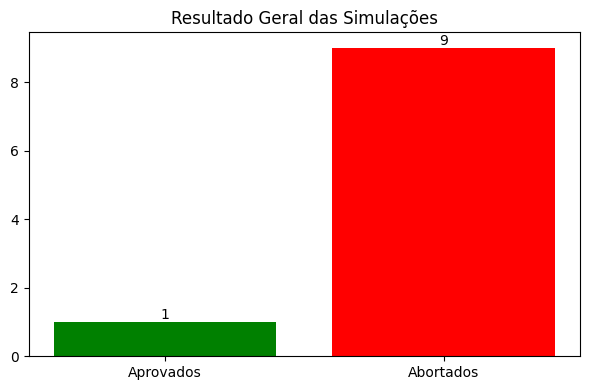

In [ ]:
aprovados = resultados.count("PRONTO PARA DECOLAR")
abortados = resultados.count("DECOLAGEM ABORTADA")

labels = ["Aprovados", "Abortados"]
valores = [aprovados, abortados]

cores = ["green", "red"]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, valores, color=cores)

for bar in bars:
    altura = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, altura,
            str(altura),
            ha='center', va='bottom')

plt.title("Resultado Geral das Simulações")
plt.tight_layout()
plt.show()

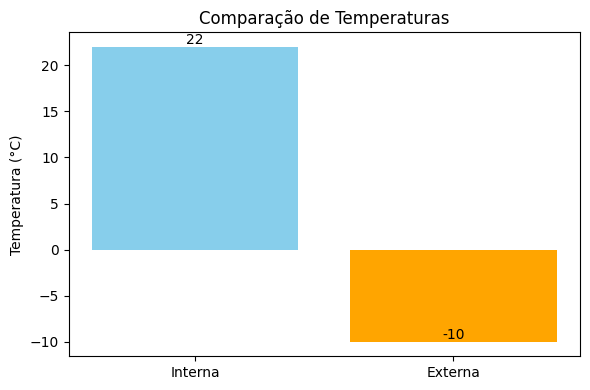

In [49]:
temps = [dados["temp_interna"], dados["temp_externa"]]
labels = ["Interna", "Externa"]


cores = ["skyblue", "orange"]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, temps, color=cores)

for bar in bars:
    altura = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, altura,
            str(altura),
            ha='center', va='bottom')

plt.title("Comparação de Temperaturas")
plt.ylabel("Temperatura (°C)")

plt.tight_layout()
plt.show()

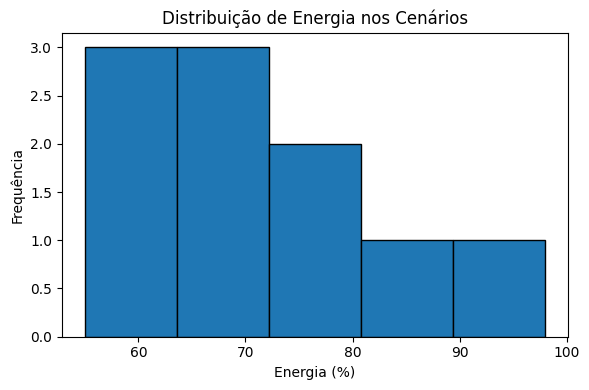

In [ ]:
energias = [c["energia"] for c in cenarios]

plt.figure(figsize=(6, 4))
plt.hist(energias, bins=5, edgecolor="black")

plt.title("Distribuição de Energia nos Cenários")
plt.xlabel("Energia (%)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()